In [9]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [16]:
file_path = "amazon_reviews_us_Digital_Video_Download_v1_00.tsv"
df = dd.read_csv(file_path, sep='\t', dtype=str, blocksize="64MB", engine="python", on_bad_lines='skip')


In [17]:
print("Columns:", df.columns)


Columns: Index(['marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date'],
      dtype='object')


In [18]:
df = df[['star_rating', 'helpful_votes', 'total_votes', 'verified_purchase', 'review_body']]

df = df.dropna()


In [19]:
df['star_rating'] = df['star_rating'].astype(int)
df['helpful_votes'] = df['helpful_votes'].astype(int)
df['total_votes'] = df['total_votes'].astype(int)

df['verified_purchase'] = df['verified_purchase'].map({'Y': 1, 'N': 0})

df['is_positive'] = df['star_rating'].map(lambda x: 1 if int(x) >= 4 else 0)


d:\UniverStudy\BigData\.venv\Lib\site-packages\dask\dataframe\dask_expr\_collection.py:4210: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map function that you are using.
  Before: .map(func)
  After:  .map(func, meta=('verified_purchase', 'float64'))

  warnings.warn(meta_warning(meta, method="map"))
d:\UniverStudy\BigData\.venv\Lib\site-packages\dask\dataframe\dask_expr\_collection.py:4210: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map function that you are using.
  Before: .map(func)
  After:  .map(func

In [20]:
df_sample = df.sample(frac=0.1).compute()

X = df_sample[['helpful_votes', 'total_votes', 'verified_purchase']]
y = df_sample['is_positive']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8232473710565849
              precision    recall  f1-score   support

           0       0.74      0.22      0.34     16543
           1       0.83      0.98      0.90     63337

    accuracy                           0.82     79880
   macro avg       0.79      0.60      0.62     79880
weighted avg       0.81      0.82      0.78     79880



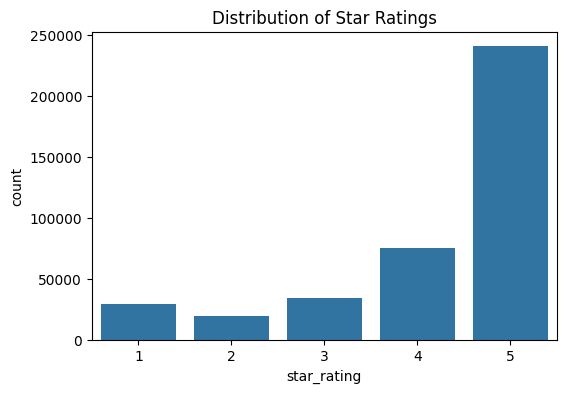

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_sample, x='star_rating')
plt.title("Distribution of Star Ratings")
plt.show()

In [23]:
df_cleaned = df[['helpful_votes', 'total_votes', 'verified_purchase', 'star_rating', 'is_positive']].compute()
df_cleaned.to_csv("clean_amazon_reviews_full.csv", index=False)
